In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os as os
import re as re
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib

from matplotlib.lines import Line2D
import matplotlib
import matplotlib.colors as mcolors
from matplotlib.colors import PowerNorm

In [2]:
# Read in the clustering data which Michael sent me
files = pd.read_csv('../data/Radius_100_patient_id_edited.csv')
files.head()

,Unnamed: 0,Entry ID,Cell ID,Cell Type,Neg,CD8_T,CD4_T,Endothelial,Stromal,HSPC,UMAP_1,UMAP_2,Leiden_Group,PID,tp,pid_tp
0,0,7142785f-c543-4768-9a8c-3153238275a9,5,CD8_T,14.514444,2.689997,0.000000,0.508647,0.473824,2.789986,-2.888258,-2.316883,18,P08,C1,P08_C1
1,1,7142785f-c543-4768-9a8c-3153238275a9,8,CD8_T,14.988450,2.622916,0.000000,0.522399,0.407936,3.250461,-2.888675,-2.320224,18,P08,C1,P08_C1
2,2,7142785f-c543-4768-9a8c-3153238275a9,95,CD8_T,15.129865,2.792207,0.000000,0.760356,0.000000,0.379367,-3.360949,-2.057606,13,P08,C1,P08_C1
3,3,7142785f-c543-4768-9a8c-3153238275a9,148,CD8_T,17.181909,3.216538,0.000000,1.220715,0.000000,0.426072,-4.089715,-1.429748,13,P08,C1,P08_C1
4,4,7142785f-c543-4768-9a8c-3153238275a9,153,CD8_T,4.583257,1.000000,0.710311,0.000000,3.059426,2.314174,-5.261656,8.218327,8,P08,C1,P08_C1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045608,1046937,33277076-7c0c-455a-90c9-f2dc9968c39d,34671,HSPC,8.025754,0.000000,0.000000,1.920477,0.000000,2.824589,-2.831910,3.443634,11,P21,C1,P21_C1
1045609,1046938,33277076-7c0c-455a-90c9-f2dc9968c39d,34691,HSPC,9.053919,0.000000,0.000000,1.877296,0.000000,2.880094,-2.119202,3.072119,5,P21,C1,P21_C1
1045610,1046939,33277076-7c0c-455a-90c9-f2dc9968c39d,34702,HSPC,22.670587,0.000000,1.499274,1.339609,0.000000,4.012542,-1.227022,-0.825529,29,P21,C1,P21_C1
1045611,1046940,33277076-7c0c-455a-90c9-f2dc9968c39d,34703,HSPC,22.991540,0.000000,1.984655,1.308631,0.000000,3.779023,-1.237542,-0.868958,29,P21,C1,P21_C1


In [3]:
# Read in data which specifies the color of each cell type
colors = pd.read_excel('../data/cell_type_colors.xlsx', sheet_name = '2026_02_23')
colors = colors.loc[colors['Cell_Type'] != 'Neg', :] # Remove the negative cells which I am not plotting
color_dict = dict(zip(colors['Cell_Type'], colors['Color']))
del color_dict['Mixed']

In [4]:
# Find the maximum for each cell typw (i.e how many cells map back to a specific hexagon)
global_vmax = {}
fig_temp, ax_temp = plt.subplots(ncols=5)
for num, i in enumerate(color_dict.keys()):
    cell = files.loc[files['Cell Type'] == i, :]
    n_cells = cell.shape[0]
    print(n_cells)
    hb = ax_temp[num].hexbin(x=cell['UMAP_1'], y=cell['UMAP_2'],
                              gridsize=30, mincnt=1,
                              C=np.ones(n_cells),
                              reduce_C_function=lambda x: len(x) / n_cells)
    global_vmax[i] = hb.get_array().max()
    
plt.close(fig_temp)


510447
120389
53043
171585
190149


In [5]:
# Read in a csv file which details the outline of the UMAP plot
outline = pd.read_csv('../data/edited_umap_outline.csv')
outline

,x,y
0,1.775218,-12.395516
1,1.673625,-12.372126
2,1.532197,-12.324951
3,1.390768,-12.259685
4,1.318584,-12.216538
...,...,...
1037,4.785053,-12.243073
1038,4.643625,-12.291336
1039,4.502196,-12.332936
1040,4.360768,-12.368438


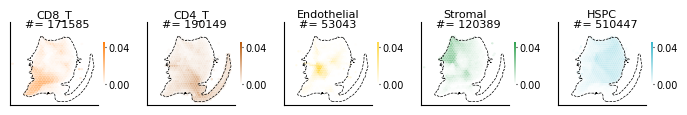

In [6]:
from matplotlib.colors import PowerNorm

order = ['CD8_T', 'CD4_T', 'Endothelial', 'Stromal', 'HSPC']


fig, ax = plt.subplots(ncols=5, figsize=(7, 1.25))

for num, i in enumerate(order):
    
    # Create a colormap from white to your color
    base_color = color_dict[i]
    cmap = LinearSegmentedColormap.from_list('custom', ['white', base_color]) #f8f8f8
    
    cell = files.loc[files['Cell Type'] == i, :]
    n_cells = cell.shape[0]
    hb = ax[num].hexbin(x=cell['UMAP_1'], y=cell['UMAP_2'], 
                   gridsize=30, cmap=cmap, mincnt=1, linewidths=0,
                   C=np.ones(n_cells),
                   reduce_C_function=lambda x: len(x) / n_cells,
                   norm=PowerNorm(gamma=0.5, vmin=0, vmax=max(global_vmax.values())))
    ax[num].plot(outline['x'], outline['y'], linestyle = '--', color = 'black', linewidth=0.5)
    cb = plt.colorbar(hb, ax=ax[num], shrink=0.5, ticks=[0,  0.04])
    cb.outline.set_linewidth(0.0)
    cb.ax.tick_params(labelsize=7, length=1, pad=1)
    ax[num].set_ylim(-14, 25)
    ax[num].set_xlim(-15, 15)
    #ax[num].tick_params(labelsize=7, length=1, pad=0)
    ax[num].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax[num].spines[['top', 'right']].set_visible(False)
    ax[num].set_title(str(i), fontsize=8, y=0.95)
    ax[num].text(s=f"#= {n_cells}", x=-10, y=22.5, fontsize=8)
plt.tight_layout()
#fig.savefig('../results/michael_clustering_v2/umap_hexbin_of_focal_cells_v2.pdf', dpi = 600)

In [7]:
# Add additional clinical information to the dataframe to allow for UMAP plots

outcomes = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx')
outcomes['Outcome_C6_revised_Vid'] = outcomes['Outcome_C6_revised_Vid'].replace('non-responder_2', 'Non-responder').replace('responder_1', 'Responder')
outcomes['Outcome_C12_CC486'] = outcomes['Outcome_C12_CC486'].replace('non-responder_2', 'Non-responder').replace('responder_1', 'Responder')

outcomes_6 = dict(zip(outcomes['PID'], outcomes['Outcome_C6_revised_Vid']))
outcomes_12 = dict(zip(outcomes['PID'], outcomes['Outcome_C12_CC486']))

files['outcomes_6'] = files['PID'].map(outcomes_6)
files['outcomes_12'] = files['PID'].map(outcomes_12)
files.head()

,Unnamed: 0,Entry ID,Cell ID,Cell Type,Neg,CD8_T,CD4_T,Endothelial,Stromal,HSPC,UMAP_1,UMAP_2,Leiden_Group,PID,tp,pid_tp,outcomes_6,outcomes_12
0,0,7142785f-c543-4768-9a8c-3153238275a9,5,CD8_T,14.514444,2.689997,0.000000,0.508647,0.473824,2.789986,-2.888258,-2.316883,18,P08,C1,P08_C1,Non-responder,Non-responder
1,1,7142785f-c543-4768-9a8c-3153238275a9,8,CD8_T,14.988450,2.622916,0.000000,0.522399,0.407936,3.250461,-2.888675,-2.320224,18,P08,C1,P08_C1,Non-responder,Non-responder
2,2,7142785f-c543-4768-9a8c-3153238275a9,95,CD8_T,15.129865,2.792207,0.000000,0.760356,0.000000,0.379367,-3.360949,-2.057606,13,P08,C1,P08_C1,Non-responder,Non-responder
3,3,7142785f-c543-4768-9a8c-3153238275a9,148,CD8_T,17.181909,3.216538,0.000000,1.220715,0.000000,0.426072,-4.089715,-1.429748,13,P08,C1,P08_C1,Non-responder,Non-responder
4,4,7142785f-c543-4768-9a8c-3153238275a9,153,CD8_T,4.583257,1.000000,0.710311,0.000000,3.059426,2.314174,-5.261656,8.218327,8,P08,C1,P08_C1,Non-responder,Non-responder


In [8]:
# Create a dictionary which specifies the patients and timepoints
patient_tp_dict = files.groupby('PID')['tp'].unique().to_dict()
patient_tp_dict

# Create a dictionary which specifies the patient outcomes
response_dict = {}
for x, y in patient_tp_dict.items():
    if 'C7' in y:
        response_dict[x] = outcomes_6[x]
    elif 'C12' in y:
        response_dict[x] = outcomes_12[x]
    elif 'Prog' in y:
        response_dict[x] =  'Non-responder'
    elif 'C1' in y:
        response_dict[x] = outcomes_6[x]
        
files['response'] = files['PID'].map(response_dict)

In [9]:
# Calculate the vmax for each plot so that the color scales are the same for 
response_outcomes = ['Responder', 'Non-responder']

global_vmax = {}
plot_times = ['C1']
fig_temp, ax_temp = plt.subplots(ncols=5)

for num, i in enumerate(response_outcomes):
    for suffix, mask in [('', files['tp'].isin(plot_times)), ('_not_c1', ~files['tp'].isin(plot_times))]:
        cell = files.loc[(files['response'] == i) & mask, :]
        n_cells = cell.shape[0]
        hb = ax_temp[num].hexbin(x=cell['UMAP_1'], y=cell['UMAP_2'],
                                  gridsize=30, mincnt=1,
                                  C=np.ones(n_cells),
                                  reduce_C_function=lambda x: len(x) / n_cells)
        global_vmax[i + suffix] = hb.get_array().max()

plt.close(fig_temp)

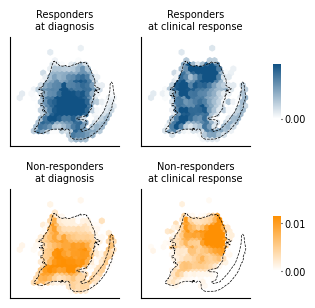

In [10]:
from matplotlib.gridspec import GridSpec

plot_times = ['C1']
response_outcomes = ['Responder', 'Non-responder']
color_dict = {'Responder': '#115284', 'Non-responder': '#fe9003'}
cmap_dict = {
    'Responder': mcolors.LinearSegmentedColormap.from_list('', ['white', color_dict['Responder']]),
    'Non-responder': mcolors.LinearSegmentedColormap.from_list('', ['white', color_dict['Non-responder']])
}
sample_counts = [
    len(files.loc[(files['response'] == 'Responder') & (files['tp'].isin(plot_times))]),
    len(files.loc[(files['response'] == 'Responder') & ~(files['tp'].isin(plot_times))]),
    len(files.loc[(files['response'] == 'Non-responder') & (files['tp'].isin(plot_times))]),
    len(files.loc[(files['response'] == 'Non-responder') & ~(files['tp'].isin(plot_times))])
]

fig = plt.figure(figsize=(3.5, 3.3872))
gs = GridSpec(2, 3, width_ratios=[1, 1, 0.08], figure=fig, hspace=0.4, wspace=0.3)

for row, y in enumerate(response_outcomes):
    ax_diag = fig.add_subplot(gs[row, 0])
    ax_resp = fig.add_subplot(gs[row, 1])
    ax_cb   = fig.add_subplot(gs[row, 2])

    # Diagnosis
    cell_diag = files.loc[(files['response'] == y) & (files['tp'].isin(plot_times))]
    n_diag = len(cell_diag)
    hb_diag = ax_diag.hexbin(
        x=cell_diag['UMAP_1'], y=cell_diag['UMAP_2'],
        gridsize=20, cmap=cmap_dict[y], mincnt=1,
        C=np.ones(n_diag),
        reduce_C_function=lambda x: len(x) / n_diag,
        norm=PowerNorm(gamma=0.5, vmin=0, vmax=global_vmax[y])
    )
    ax_diag.plot(outline['x'], outline['y'], linestyle = '--', color = 'black', linewidth=0.5)
    ax_diag.set_title(y + 's\nat diagnosis', fontsize=7)

    # Clinical response
    cell_resp = files.loc[(files['response'] == y) & ~(files['tp'].isin(plot_times))]
    n_resp = len(cell_resp)
    hb_resp = ax_resp.hexbin(
        x=cell_resp['UMAP_1'], y=cell_resp['UMAP_2'],
        gridsize=20, cmap=cmap_dict[y], mincnt=1,
        C=np.ones(n_resp),
        reduce_C_function=lambda x: len(x) / n_resp,
        norm=PowerNorm(gamma=0.5, vmin=0, vmax=global_vmax[y + '_not_c1'])
    )
    ax_resp.plot(outline['x'], outline['y'], linestyle = '--', color = 'black', linewidth=0.5)
    ax_resp.set_title(y + 's\nat clinical response', fontsize=7)

    # Colorbar in dedicated column
    cb = fig.colorbar(hb_resp, cax=ax_cb, ticks=[0, 0.01])
    cb.outline.set_linewidth(0.0)
    cb.ax.tick_params(labelsize=7, length=1, pad=1)

    # Shrink the colorbar height
    pos = ax_cb.get_position()
    shrink = 0.5  # fraction of original height
    new_height = pos.height * shrink
    new_y = pos.y0 + (pos.height - new_height) / 2  # keep it centred
    ax_cb.set_position([pos.x0, new_y, pos.width, new_height])

    for axis in [ax_diag, ax_resp]:
        axis.spines[['top', 'right']].set_visible(False)
        axis.set_xticks([])
        axis.set_yticks([])
        axis.set_xlim(-17.5, 15)
        axis.set_ylim(-15, 27.5)



In [11]:
response_outcomes

['Responder', 'Non-responder']